In [2]:
import pandas as pd

# File Path
file_path = r"D:\Masters Study Abroad\BA 2nd Sem\IS6611 Applied Research in Business Analytics\IS6611 IT Artefact V3\Old Datasets\US Stocks\NASDAQ_Combined_Dataset.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort the dataframe by Date (just in case)
df = df.sort_values(by='Date')

# Set 'Date' as index (optional, useful for time series analysis)
df.set_index('Date', inplace=True)

# Show basic info and first few rows
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-06-30 to 2025-06-30
Columns: 500 entries, AAPL_Close/Last to ZS_Low
dtypes: float64(100), object(400)
memory usage: 9.6+ MB
None
           AAPL_Close/Last  AAPL_Volume AAPL_Open AAPL_High  AAPL_Low  \
Date                                                                    
2015-06-30        $31.3562  177304200.0  $31.3925    $31.53   $31.215   
2015-07-01          $31.65  120827560.0   $31.725   $31.735  $31.4975   
2015-07-02          $31.61  108684720.0  $31.6075  $31.6725  $31.4425   
2015-07-06          $31.50  111891800.0   $31.235  $31.5575  $31.2125   
2015-07-07        $31.4225  186948360.0  $31.4725  $31.5375  $30.9425   

           Abnb_Close/Last  Abnb_Volume Abnb_Open Abnb_High Abnb_Low  ...  \
Date                                                                  ...   
2015-06-30             NaN          NaN       NaN       NaN      NaN  ...   
2015-07-01             NaN          NaN       NaN       

C:\Users\shamg\AppData\Local\Temp\ipykernel_20764\3508888778.py:7: DtypeWarning: Columns (66,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
# Drop Open, High, Low columns (not needed)
cols_to_drop = [col for col in df.columns if '_Open' in col or '_High' in col or '_Low' in col]
df.drop(columns=cols_to_drop, inplace=True)

# Confirm new shape and remaining columns
print(f"Dataset shape after dropping: {df.shape}")
print("Sample columns:", df.columns[:10].tolist())


Dataset shape after dropping: (2515, 200)
Sample columns: ['AAPL_Close/Last', 'AAPL_Volume', 'Abnb_Close/Last', 'Abnb_Volume', 'adbe_Close/Last', 'adbe_Volume', 'adi_Close/Last', 'adi_Volume', 'adp_Close/Last', 'adp_Volume']


In [4]:
# Identify Close and Volume columns
close_cols = [col for col in df.columns if '_Close/Last' in col]
volume_cols = [col for col in df.columns if '_Volume' in col]

# Function to clean and convert dollar-formatted strings to float
def clean_dollar_column(col):
    return col.replace(r'[\$,]', '', regex=True).astype(float)

# Clean Close/Last columns
df[close_cols] = df[close_cols].apply(clean_dollar_column)

# Ensure Volume columns are also float (in case of string or mixed types)
df[volume_cols] = df[volume_cols].apply(pd.to_numeric, errors='coerce')

# Confirm cleanup worked
print(df[close_cols[:3] + volume_cols[:3]].head())

            AAPL_Close/Last  Abnb_Close/Last  adbe_Close/Last  AAPL_Volume  \
Date                                                                         
2015-06-30          31.3562              NaN              NaN  177304200.0   
2015-07-01          31.6500              NaN           80.945  120827560.0   
2015-07-02          31.6100              NaN           80.750  108684720.0   
2015-07-06          31.5000              NaN           80.500  111891800.0   
2015-07-07          31.4225              NaN           80.590  186948360.0   

            Abnb_Volume  adbe_Volume  
Date                                  
2015-06-30          NaN          NaN  
2015-07-01          NaN    2944493.0  
2015-07-02          NaN    2200892.0  
2015-07-06          NaN    2590913.0  
2015-07-07          NaN    2781935.0  


In [5]:
import numpy as np

cagr_results = []

# Loop through all Close/Last columns
for col in close_cols:
    stock_series = df[col].dropna()
    
    # Skip if not enough data
    if stock_series.shape[0] < 2:
        continue

    start_price = stock_series.iloc[0]
    end_price = stock_series.iloc[-1]
    start_date = stock_series.index[0]
    end_date = stock_series.index[-1]
    
    # Calculate the number of years between start and end
    years = (end_date - start_date).days / 365.25

    if start_price > 0 and years > 0:
        cagr = (end_price / start_price) ** (1 / years) - 1
        cagr_results.append({
            'Stock': col.replace('_Close/Last', ''),
            'CAGR': cagr,
            'Start Date': start_date.date(),
            'End Date': end_date.date()
        })

# Convert to DataFrame
cagr_df = pd.DataFrame(cagr_results)

# Add a percentage column to make interpretation easier
cagr_df['CAGR (%)'] = cagr_df['CAGR'] * 100

# Repeat the sort with new column
cagr_df_sorted = cagr_df.sort_values(by='CAGR', ascending=False)

# Refresh top/bottom
top_5 = cagr_df_sorted.head(5).reset_index(drop=True)
bottom_5 = cagr_df_sorted.tail(5).reset_index(drop=True)

# Display again
print("Top 5 Performing Stocks by CAGR (%):\n")
print(top_5[['Stock', 'CAGR (%)', 'Start Date', 'End Date']])

print("\nBottom 5 Performing Stocks by CAGR (%):\n")
print(bottom_5[['Stock', 'CAGR (%)', 'Start Date', 'End Date']])


Top 5 Performing Stocks by CAGR (%):

  Stock   CAGR (%)  Start Date    End Date
0   ceg  80.605866  2022-01-19  2025-06-27
1  NVDA  77.757694  2015-06-30  2025-06-27
2  PLTR  73.887526  2020-09-30  2025-06-27
3   arm  70.865017  2023-09-14  2025-06-27
4   amd  50.618922  2015-06-30  2025-06-27

Bottom 5 Performing Stocks by CAGR (%):

  Stock   CAGR (%)  Start Date    End Date
0  INTC  -2.889553  2015-06-30  2025-06-27
1   gfs  -5.021300  2021-10-28  2025-06-27
2   KHC  -9.961880  2015-07-06  2025-06-27
3   WBD -10.239863  2015-06-30  2025-06-27
4  biib -10.410625  2015-06-30  2025-06-27


# ARIMA Forecasting

C:\Users\shamg\AppData\Local\Temp\ipykernel_20764\665800145.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts_close = ts_close.asfreq('B').fillna(method='ffill')


ADF Statistic: -0.2127
p-value: 0.9370
=> Series is NOT stationary


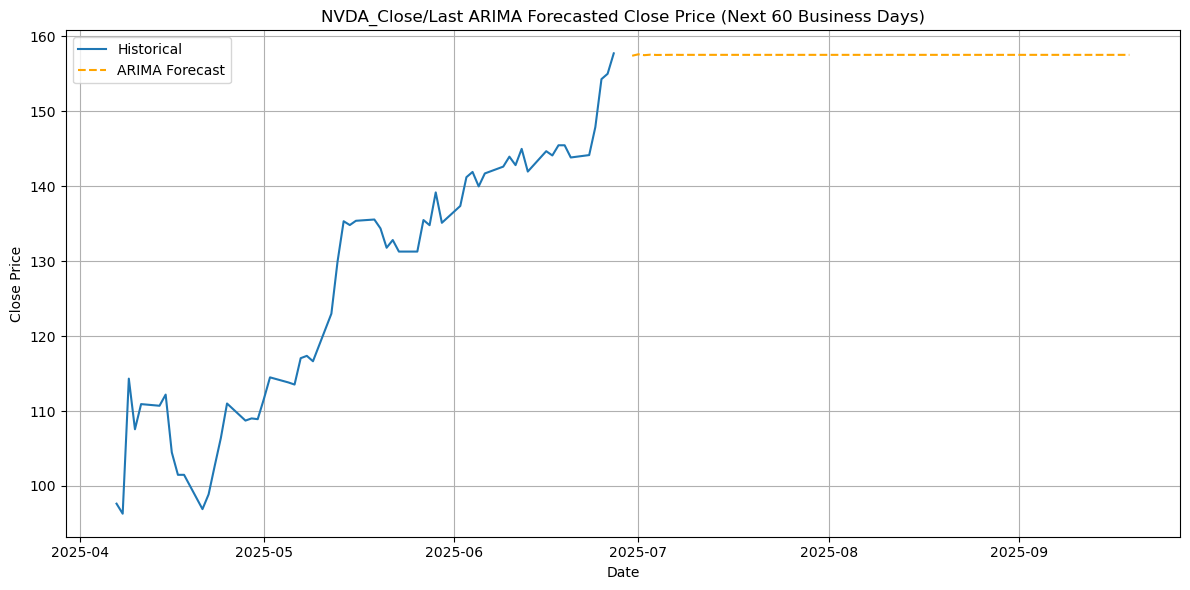


ARIMA Model Summary for NVDA_Close/Last:
                               SARIMAX Results                                
Dep. Variable:        NVDA_Close/Last   No. Observations:                  785
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1919.273
Date:                Wed, 09 Jul 2025   AIC                           3844.546
Time:                        10:54:44   BIC                           3858.540
Sample:                    06-27-2022   HQIC                          3849.927
                         - 06-27-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5958      0.158     -3.761      0.000      -0.906      -0.285
ma.L1          0.5065      0.168      3.018      0.003       0.178       0.835
sigma2    

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# 1. Define the stock
stock = 'NVDA_Close/Last'

# 2. Prepare the univariate data (only CLOSE)
ts_close = df[f'{stock}'].dropna()

# 3. Use only the last 3 years
end_date = ts_close.index.max()
start_cutoff = end_date - pd.DateOffset(years=3)
ts_close = ts_close.loc[ts_close.index >= start_cutoff]

# 4. Set business day frequency and fill missing values
ts_close = ts_close.asfreq('B').fillna(method='ffill')

# 5. Test for stationarity (ADF test)
adf_result = adfuller(ts_close)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("=> Series is stationary" if adf_result[1] < 0.05 else "=> Series is NOT stationary")

# 6. Difference the series if needed
ts_diff = ts_close.diff().dropna() if adf_result[1] > 0.05 else ts_close

# 7. Fit ARIMA model (you can tune (p,d,q) — this is just an example)
# You can use auto_arima from pmdarima to choose optimal order
model = ARIMA(ts_close, order=(1, 1, 2))  # (p, d, q)
fitted_arima = model.fit()

# 8. Forecast next 60 business days
forecast_steps = 60
forecast = fitted_arima.forecast(steps=forecast_steps)

# 9. Create forecast index
forecast_dates = pd.date_range(start=ts_close.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='B')
forecast.index = forecast_dates

# 10. Plot the results
plt.figure(figsize=(12, 6))
plt.plot(ts_close[-60:], label='Historical')
plt.plot(forecast, label='ARIMA Forecast', linestyle='--', color='orange')
plt.title(f"{stock} ARIMA Forecasted Close Price (Next {forecast_steps} Business Days)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 11. Print summary
print(f"\nARIMA Model Summary for {stock}:")
print(fitted_arima.summary())
